In [1]:
import os
import json
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [2]:
DATASET_PATH = r"C:\Users\MALAY\sentinel\ai\datasets\paysim_engineered.csv"

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Dataset:", DATASET_PATH)

Dataset exists: True
Dataset: C:\Users\MALAY\sentinel\ai\datasets\paysim_engineered.csv


In [3]:
df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (500000, 19)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_balance_change,dest_balance_change,balance_error_orig,balance_error_dest,amount_to_orig_balance,amount_to_dest_balance,hour,day
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0,-330218.42,-330218.42,-660436.84,660436.84,1.582491e+01,0.729893,14,11
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0,11647.08,0.00,0.00,11647.08,3.834935e-01,11647.080000,15,0
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0,-152264.21,-152264.21,-304528.42,304528.42,1.428504e+00,0.756389,10,0
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0,0.00,1551760.63,-1551760.63,0.00,1.551761e+06,0.485174,19,16
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0,-78172.30,-78172.30,-156344.60,156344.60,2.675912e-02,0.187994,14,8


In [4]:
print("Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:

1. step
2. type
3. amount
4. nameOrig
5. oldbalanceOrg
6. newbalanceOrig
7. nameDest
8. oldbalanceDest
9. newbalanceDest
10. isFraud
11. isFlaggedFraud
12. orig_balance_change
13. dest_balance_change
14. balance_error_orig
15. balance_error_dest
16. amount_to_orig_balance
17. amount_to_dest_balance
18. hour
19. day


In [5]:
print(df["isFraud"].value_counts())

print("\nFraud percentage:")
print(df["isFraud"].mean() * 100)

isFraud
0    499353
1       647
Name: count, dtype: int64

Fraud percentage:
0.12940000000000002


In [6]:
DROP_COLUMNS = [
    "nameOrig",
    "nameDest"
]

df = df.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'orig_balance_change', 'dest_balance_change', 'balance_error_orig', 'balance_error_dest', 'amount_to_orig_balance', 'amount_to_dest_balance', 'hour', 'day']


In [7]:
TARGET = "isFraud"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500000, 16)
y shape: (500000,)


In [8]:
print(X.dtypes)

step                        int64
type                          str
amount                    float64
oldbalanceOrg             float64
newbalanceOrig            float64
oldbalanceDest            float64
newbalanceDest            float64
isFlaggedFraud              int64
orig_balance_change       float64
dest_balance_change       float64
balance_error_orig        float64
balance_error_dest        float64
amount_to_orig_balance    float64
amount_to_dest_balance    float64
hour                        int64
day                         int64
dtype: object


In [9]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['type']

Numerical features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'orig_balance_change', 'dest_balance_change', 'balance_error_orig', 'balance_error_dest', 'amount_to_orig_balance', 'amount_to_dest_balance', 'hour', 'day']


C:\Users\MALAY\AppData\Local\Temp\ipykernel_20176\3548691148.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining fraud rate:")
print(y_train.mean())

print("\nTesting fraud rate:")
print(y_test.mean())

Training data: (400000, 16)
Testing data: (100000, 16)

Training fraud rate:
0.001295

Testing fraud rate:
0.00129


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [12]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Legitimate transactions:", negative_count)
print("Fraud transactions:", positive_count)

print(
    "scale_pos_weight:",
    scale_pos_weight
)

Legitimate transactions: 399482
Fraud transactions: 518
scale_pos_weight: 771.2007722007722


In [13]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="liblinear"
            )
        )
    ]
)

In [14]:
print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [15]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [16]:
print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [17]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=8,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="aucpr",
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [18]:
print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

Training XGBoost...
XGBoost training completed!


In [19]:
def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

In [20]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.95529,
 'Precision': 0.027427078798432737,
 'Recall': 0.9767441860465116,
 'F1': 0.0533559178488249,
 'ROC-AUC': 0.9950213294529787,
 'PR-AUC': 0.6119628699493552}

In [21]:
random_forest_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.99999,
 'Precision': 0.9923076923076923,
 'Recall': 1.0,
 'F1': 0.9961389961389961,
 'ROC-AUC': 0.999999922380491,
 'PR-AUC': 0.9999403697078115}

In [22]:
xgb_results = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.99992,
 'Precision': 0.9689922480620154,
 'Recall': 0.9689922480620154,
 'F1': 0.9689922480620154,
 'ROC-AUC': 0.9999954980684773,
 'PR-AUC': 0.9963576221868776}

In [23]:
results = pd.DataFrame([
    logistic_results,
    random_forest_results,
    xgb_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.95529,0.027427,0.976744,0.053356,0.995021,0.611963
1,Random Forest,0.99999,0.992308,1.000000,0.996139,1.000000,0.999940
2,XGBoost,0.99992,0.968992,0.968992,0.968992,0.999995,0.996358


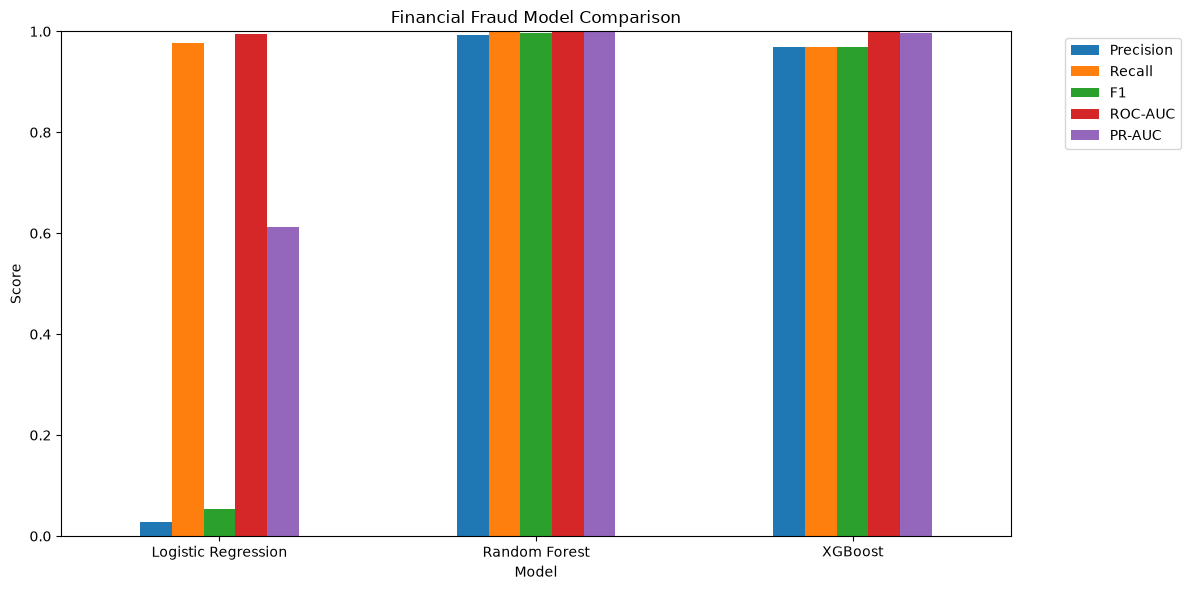

In [24]:
metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

results_plot = results.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Financial Fraud Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [25]:
best_model_name = results.loc[
    results["F1"].idxmax(),
    "Model"
]

print("Best model:", best_model_name)

Best model: Random Forest


In [26]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

best_model = models[best_model_name]

print(
    "Selected model:",
    best_model_name
)

Selected model: Random Forest


In [27]:
best_predictions = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     99871
       Fraud       0.99      1.00      1.00       129

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



In [28]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

print(cm)

[[99870     1]
 [    0   129]]


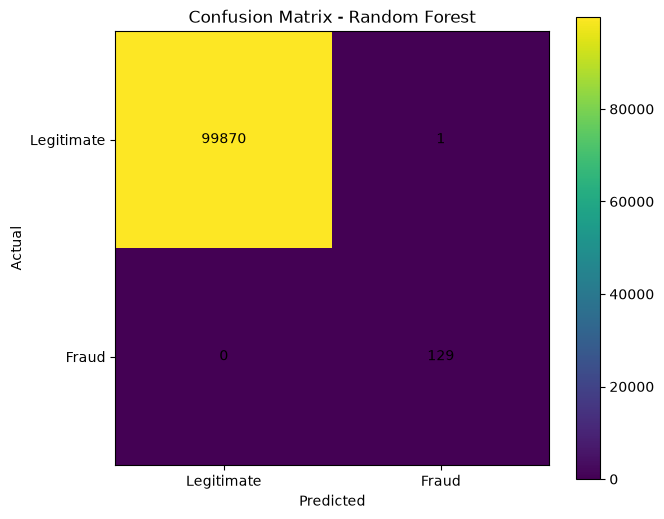

In [29]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [30]:
MODEL_DIR = r"C:\Users\MALAY\sentinel\ai\models\financial"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

print("Model directory ready:")
print(MODEL_DIR)

Model directory ready:
C:\Users\MALAY\sentinel\ai\models\financial


In [31]:
MODEL_PATH = os.path.join(
    MODEL_DIR,
    "financial_model.pkl"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
C:\Users\MALAY\sentinel\ai\models\financial\financial_model.pkl


In [32]:
feature_information = {
    "target": TARGET,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "model": best_model_name,
    "threshold": 0.50
}

FEATURE_INFO_PATH = os.path.join(
    MODEL_DIR,
    "financial_features.json"
)

with open(
    FEATURE_INFO_PATH,
    "w"
) as f:

    json.dump(
        feature_information,
        f,
        indent=4
    )

print("Feature information saved:")
print(FEATURE_INFO_PATH)

Feature information saved:
C:\Users\MALAY\sentinel\ai\models\financial\financial_features.json


In [33]:
metadata = {
    "model_name": best_model_name,
    "dataset": "PaySim",
    "target": "isFraud",
    "training_rows": int(len(X_train)),
    "testing_rows": int(len(X_test)),
    "accuracy": float(
        results.loc[
            results["Model"] == best_model_name,
            "Accuracy"
        ].iloc[0]
    ),
    "precision": float(
        results.loc[
            results["Model"] == best_model_name,
            "Precision"
        ].iloc[0]
    ),
    "recall": float(
        results.loc[
            results["Model"] == best_model_name,
            "Recall"
        ].iloc[0]
    ),
    "f1": float(
        results.loc[
            results["Model"] == best_model_name,
            "F1"
        ].iloc[0]
    ),
    "roc_auc": float(
        results.loc[
            results["Model"] == best_model_name,
            "ROC-AUC"
        ].iloc[0]
    ),
    "pr_auc": float(
        results.loc[
            results["Model"] == best_model_name,
            "PR-AUC"
        ].iloc[0]
    )
}

METADATA_PATH = os.path.join(
    MODEL_DIR,
    "financial_model_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print("Metadata saved:")
print(METADATA_PATH)

Metadata saved:
C:\Users\MALAY\sentinel\ai\models\financial\financial_model_metadata.json


In [34]:
print("\nFinancial model files:\n")

for file in os.listdir(MODEL_DIR):
    print("✓", file)


Financial model files:

✓ financial_features.json
✓ financial_model.pkl
✓ financial_model_metadata.json


In [35]:
loaded_model = joblib.load(
    MODEL_PATH
)

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [36]:
sample_transaction = X_test.iloc[[0]]

print(sample_transaction)

        step     type     amount  oldbalanceOrg  newbalanceOrig  \
331901   322  CASH_IN  362120.57     5722664.65      6084785.22   

        oldbalanceDest  newbalanceDest  isFlaggedFraud  orig_balance_change  \
331901      3261861.29      2899740.72               0           -362120.57   

        dest_balance_change  balance_error_orig  balance_error_dest  \
331901           -362120.57          -724241.14           724241.14   

        amount_to_orig_balance  amount_to_dest_balance  hour  day  
331901                0.063278                0.111017    10   13  


In [37]:
prediction = loaded_model.predict(
    sample_transaction
)[0]

probability = loaded_model.predict_proba(
    sample_transaction
)[0][1]

print("Prediction:", prediction)

print(
    f"Fraud probability: {probability * 100:.2f}%"
)

Prediction: 0
Fraud probability: 0.00%


In [38]:
def get_risk_level(probability):

    if probability >= 0.80:
        return "HIGH"

    elif probability >= 0.50:
        return "MEDIUM"

    elif probability >= 0.20:
        return "LOW"

    else:
        return "MINIMAL"

In [39]:
risk_probability = probability

risk_level = get_risk_level(
    risk_probability
)

print(
    f"Fraud Probability: {risk_probability * 100:.2f}%"
)

print(
    f"Risk Level: {risk_level}"
)

Fraud Probability: 0.00%
Risk Level: MINIMAL


In [40]:
print("=" * 50)
print("       SENTINEL FINANCIAL THREAT DETECTION")
print("=" * 50)

print()

print(
    f"Fraud Probability : {probability * 100:.2f}%"
)

print(
    f"Risk Level        : {risk_level}"
)

print(
    f"Prediction        : "
    f"{'FRAUD' if prediction == 1 else 'LEGITIMATE'}"
)

print("=" * 50)

       SENTINEL FINANCIAL THREAT DETECTION

Fraud Probability : 0.00%
Risk Level        : MINIMAL
Prediction        : LEGITIMATE
